In [1]:
# Libraries
import pandas as pd
from mlxtend.frequent_patterns import association_rules, apriori

In [2]:
# Dataset
dataset = pd.read_csv("data/groceries.csv")
dataset.head()

,Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,Item 10,...,Item 13,Item 14,Item 15,Item 16,Item 17,Item 18,Item 19,Item 20,Item 21,Item 22
0,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
dataset.shape

(9835, 22)

In [4]:
# Transaction list
transactions = []
for i in range (0, 9835):
  transactions.append([str(dataset.values[i,j])
                      for j in range (0,22)])
transactions

[['citrus fruit',
  'semi-finished bread',
  'margarine',
  'ready soups',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['tropical fruit',
  'yogurt',
  'coffee',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['whole milk',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['pip fruit',
  'yogurt',
  'cream cheese ',
  'meat spreads',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product',
  'nan',
  'nan',
  'nan'

In [6]:
# Encode the transactions
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_transactions = te.fit_transform(transactions)
df = pd.DataFrame(te_transactions,
                  columns = te.columns_)
df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [7]:
# Remove this nan columns
df = df.drop(columns = 'nan')

In [8]:
# ARL
model = apriori(df, min_support= 0.03, use_colnames=True)
results = association_rules(model,
                            metric = 'confidence',
                            min_threshold = 0.3)
results.sort_values(by = 'lift', ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(root vegetables),(other vegetables),0.108998,0.193493,0.047382,0.434701,2.246605,1.0,0.026291,1.426693,0.622764,0.185731,0.299078,0.339789
8,(sausage),(rolls/buns),0.093950,0.183935,0.030605,0.325758,1.771048,1.0,0.013324,1.210344,0.480506,0.123766,0.173788,0.246074
3,(tropical fruit),(other vegetables),0.104931,0.193493,0.035892,0.342054,1.767790,1.0,0.015589,1.225796,0.485239,0.136716,0.184204,0.263775
12,(whipped/sour cream),(whole milk),0.071683,0.255516,0.032232,0.449645,1.759754,1.0,0.013916,1.352735,0.465077,0.109273,0.260757,0.287895
10,(root vegetables),(whole milk),0.108998,0.255516,0.048907,0.448694,1.756031,1.0,0.021056,1.350401,0.483202,0.154961,0.259479,0.320049
5,(yogurt),(other vegetables),0.139502,0.193493,0.043416,0.311224,1.608457,1.0,0.016424,1.170929,0.439613,0.149930,0.145977,0.267804
11,(tropical fruit),(whole milk),0.104931,0.255516,0.042298,0.403101,1.577595,1.0,0.015486,1.247252,0.409045,0.132950,0.198238,0.284320
13,(yogurt),(whole milk),0.139502,0.255516,0.056024,0.401603,1.571735,1.0,0.020379,1.244132,0.422732,0.165267,0.196226,0.310432
7,(pip fruit),(whole milk),0.075648,0.255516,0.030097,0.397849,1.557043,1.0,0.010767,1.236375,0.387036,0.099966,0.191184,0.257818
4,(other vegetables),(whole milk),0.193493,0.255516,0.074835,0.386758,1.513634,1.0,0.025394,1.214013,0.420750,0.200000,0.176286,0.339817


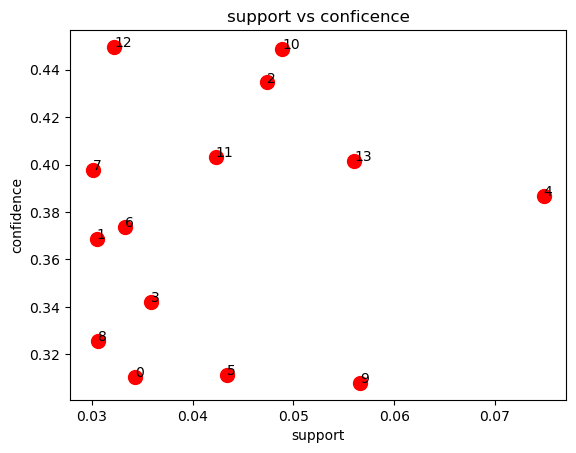

In [9]:
# Visualization
import matplotlib.pyplot as plt
plt.scatter(results['support'],
            results['confidence'],
            s = 100,
            color = 'red')
plt.xlabel('support')
plt.ylabel('confidence')
plt.title('support vs conficence')
for i, label in  enumerate(results.index):
  plt.annotate(label, (results['support'][i],
               results['confidence'][i]))
plt.show()

In [10]:
# Load data
dataset = pd.read_csv("data/restaurants-challenge.csv", header = None)
dataset.head()

,0,1,2
0,BROOKLYN,Chinese,Z
1,MANHATTAN,American,C
2,BRONX,Chicken,C
3,MANHATTAN,American,A
4,MANHATTAN,American,A


In [11]:
dataset.shape

(179731, 3)

In [12]:
# List
transactions = []
for i in range ( 0, 179731):
  transactions.append([str(dataset.values[i,j])
                      for j in range (0,3)])
transactions[:5]

[[' BROOKLYN ', ' Chinese ', ' Z'],
 [' MANHATTAN ', ' American ', ' C'],
 [' BRONX ', ' Chicken ', ' C'],
 [' MANHATTAN ', ' American ', ' A'],
 [' MANHATTAN ', ' American ', ' A']]

In [13]:
# Encoding transaction list
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_transactions = te.fit_transform(transactions)
df = pd.DataFrame(te_transactions,
                  columns = te.columns_)
df.head()

,A,Afghan,African,American,Armenian,Asian,Australian,B,BRONX,BROOKLYN,...,Southwestern,Spanish,Steak,Tapas,Tex-Mex,Thai,Turkish,Vegetarian,Vietnamese/Cambodian/Malaysia,Z
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
# ARL
model = apriori(df, min_support=0.02, use_colnames=True)
results = association_rules(model,
                            metric = 'confidence',
                            min_threshold = 0.5)
results.sort_values(by = 'lift', ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
9,( Italian ),( MANHATTAN ),0.047671,0.412644,0.029394,0.616597,1.494256,1.0,0.009723,1.531952,0.347328,0.068212,0.347238,0.343915
3,( Cafe/Coffee/Tea ),( A),0.032120,0.513078,0.022016,0.685432,1.335922,1.0,0.005536,1.547908,0.259798,0.042081,0.353967,0.364171
8,( American ),( MANHATTAN ),0.239163,0.412644,0.129866,0.543003,1.315911,1.0,0.031177,1.285251,0.315534,0.248814,0.221942,0.428860
14,"( American , B)",( MANHATTAN ),0.061208,0.412644,0.033227,0.542860,1.315563,1.0,0.007970,1.284848,0.255508,0.075410,0.221698,0.311691
11,"( American , A)",( MANHATTAN ),0.134401,0.412644,0.072642,0.540487,1.309812,1.0,0.017182,1.278213,0.273258,0.153123,0.217658,0.358263
7,( STATENISLAND ),( A),0.032326,0.513078,0.021026,0.650430,1.267703,1.0,0.004440,1.392919,0.218226,0.040097,0.282083,0.345705
0,( American ),( A),0.239163,0.513078,0.134401,0.561963,1.095279,1.0,0.011692,1.111602,0.114336,0.217533,0.100397,0.411957
12,"( American , MANHATTAN )",( A),0.129866,0.513078,0.072642,0.559359,1.090203,1.0,0.006010,1.105032,0.095088,0.127374,0.095048,0.350470
10,"( American , BROOKLYN )",( A),0.045329,0.513078,0.025238,0.556769,1.085156,1.0,0.001980,1.098575,0.082199,0.047335,0.089730,0.302979
13,"( American , QUEENS )",( A),0.040071,0.513078,0.022000,0.549014,1.070041,1.0,0.001440,1.079684,0.068188,0.041419,0.073803,0.295946


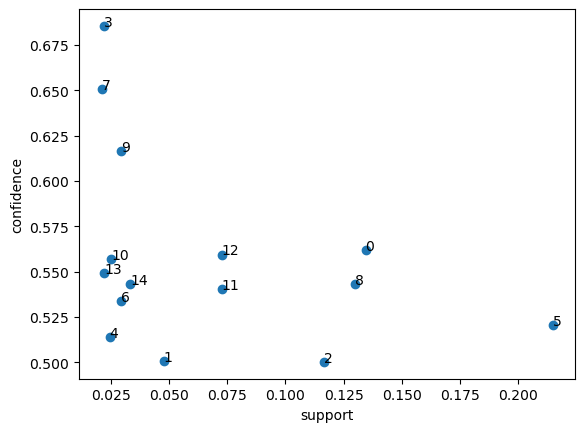

In [15]:
# Visualization
import matplotlib.pyplot as plt
plt.scatter(results['support'],
            results['confidence'])
plt.xlabel('support')
plt.ylabel('confidence')
for i, label in enumerate(results.index):
  plt.annotate(label, (results['support'][i],
                       results['confidence'][i]))
plt.show()